## Visualisation complète des images et de leurs caractéristiques

Ce notebook regroupe l'ensemble des visualisations nécessaires à l'analyse descriptive du dataset d'images.

### Objectifs :
- Mieux comprendre la composition du jeu de données (formats, orientations, tailles)
- Identifier les couleurs les plus fréquentes
- Regrouper visuellement les images par style colorimétrique (clustering RGB)

### Contenu du notebook :
1. Chargement des données annotées depuis `annotations.json`
2. Histogramme des formats d’image (`JPEG`, `PNG`, etc.)
3. Histogramme des orientations (`portrait`, `landscape`, `square`)
4. Nuage de points (scatterplot) des dimensions (largeur / hauteur)
5. Barplot des 10 couleurs dominantes les plus fréquentes
6. Clustering visuel (via KMeans) basé sur la couleur moyenne RGB de chaque image
7. Affichage des couleurs moyennes des clusters

Chaque graphique est généré automatiquement à partir des annotations collectées, sans intervention manuelle.  
Ce travail permet d’avoir une vue d’ensemble claire et exploitable du dataset image.

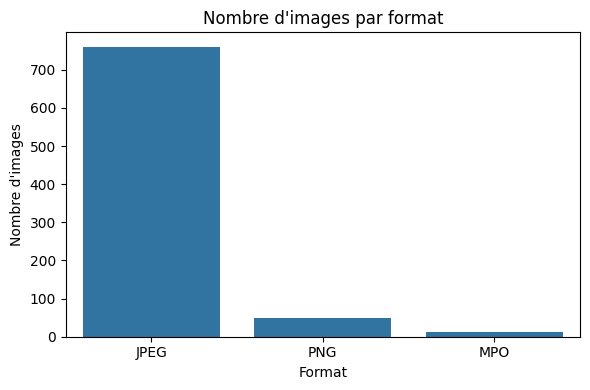

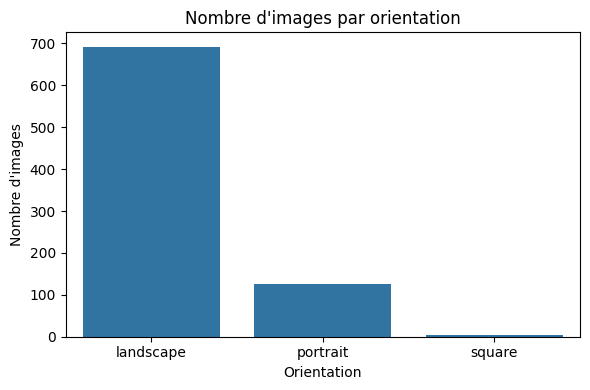

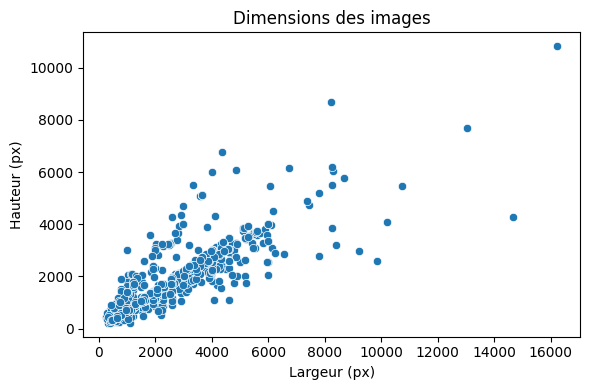

/var/folders/pk/crn_0m5s05ncksdqwqbd17100000gn/T/ipykernel_37132/731495217.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[c[0] for c in most_common], y=[c[1] for c in most_common], palette=[c[0] for c in most_common])


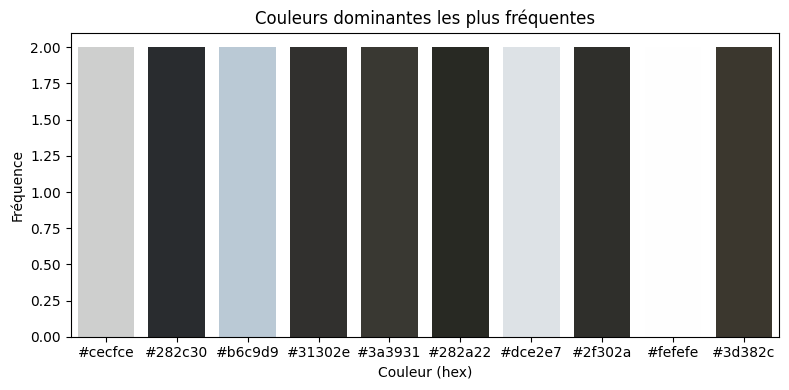

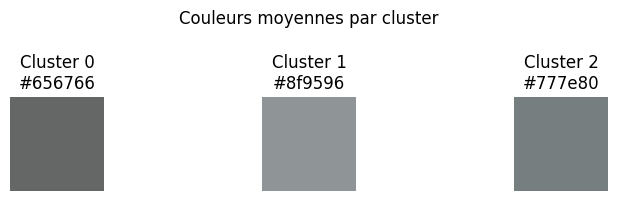

In [6]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from PIL import Image

ANNOTATION_FILE = "../annotation/JSON/annotations.json"

with open(ANNOTATION_FILE, "r", encoding="utf-8") as f:
    annotations = json.load(f)

data = []
for filename, info in annotations.items():
    meta = info["metadata"]
    data.append({
        "filename": filename,
        "format": meta.get("format"),
        "width": meta.get("size", [0, 0])[0],
        "height": meta.get("size", [0, 0])[1],
        "orientation": (
            "portrait" if meta.get("size", [0, 0])[1] > meta.get("size", [0, 0])[0]
            else "landscape" if meta.get("size", [0, 0])[0] > meta.get("size", [0, 0])[1]
            else "square"
        ),
        "colors": info.get("dominant_colors", [])
    })

df = pd.DataFrame(data)

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="format", order=df["format"].value_counts().index)
plt.title("Nombre d'images par format")
plt.xlabel("Format")
plt.ylabel("Nombre d'images")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="orientation", order=df["orientation"].value_counts().index)
plt.title("Nombre d'images par orientation")
plt.xlabel("Orientation")
plt.ylabel("Nombre d'images")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="width", y="height")
plt.title("Dimensions des images")
plt.xlabel("Largeur (px)")
plt.ylabel("Hauteur (px)")
plt.tight_layout()
plt.show()

all_colors = sum(df["colors"].tolist(), [])
color_counts = Counter(all_colors)
most_common = color_counts.most_common(10)

plt.figure(figsize=(8,4))
sns.barplot(x=[c[0] for c in most_common], y=[c[1] for c in most_common], palette=[c[0] for c in most_common])
plt.title("Couleurs dominantes les plus fréquentes")
plt.xlabel("Couleur (hex)")
plt.ylabel("Fréquence")
plt.tight_layout()
plt.show()

def hex_to_rgb(hex_color):
    hex_color = hex_color.lstrip('#')
    return tuple(int(hex_color[i:i+2], 16) for i in (0, 2, 4))

def get_average_rgb(colors):
    if not colors:
        return [0, 0, 0]
    rgbs = [hex_to_rgb(c) for c in colors]
    r = sum([rgb[0] for rgb in rgbs]) / len(rgbs)
    g = sum([rgb[1] for rgb in rgbs]) / len(rgbs)
    b = sum([rgb[2] for rgb in rgbs]) / len(rgbs)
    return [r, g, b]

df["rgb_avg"] = df["colors"].apply(get_average_rgb)

from sklearn.cluster import KMeans
import numpy as np

X_rgb = np.array(df["rgb_avg"].tolist())
kmeans = KMeans(n_clusters=3, random_state=42)
df["cluster"] = kmeans.fit_predict(X_rgb)

plt.figure(figsize=(8,2))
for i, center in enumerate(kmeans.cluster_centers_):
    rgb_color = [int(c) for c in center]
    color_hex = '#%02x%02x%02x' % tuple(rgb_color)
    plt.subplot(1, 3, i+1)
    plt.imshow(np.ones((10,10,3), dtype=np.uint8) * np.array(rgb_color, dtype=np.uint8))
    plt.axis("off")
    plt.title(f"Cluster {i}\n{color_hex}")
plt.suptitle("Couleurs moyennes par cluster")
plt.tight_layout()
plt.show()
